# 07 · Share de Coca-Cola con Whisp (opcional) → prioridad

**Regla del usuario (2026-10-05):** la prioridad de cada PDV sale de su **Letra 1** (demanda) y del **share** de Coca-Cola de su zona:

| Letra 1 | Share | Prioridad |
|---|---|---|
| H | bajo | **P1** |
| H | alto | **P2** |
| L | bajo | **P3** |
| L | alto | **P4** |

El share sale de **Whisp** (`data/raw/whisp/Whisp.csv`, ventas por hexágono H3 **res 6**, fabricante y mes): por hexágono,
share = cajas unidad de `COCA-COLA COMPANY` / cajas unidad de todos los fabricantes (sueros + isotónicos), en la ventana
`config.WHISP_VENTANA` (ago-2025 → ago-2026). **Alto** si el share del hexágono ≥ share de toda el área de estudio (índice 100,
la misma lógica que Golden Stores). También se reporta el share en revenue.

**Whisp es opcional:** solo cubre algunas regiones (hoy Occidente y CD.MX). Si no tiene datos para el área (p. ej. Mérida), este
paso lo registra y el 06 deja la prioridad por letras (HH P1 · HL P2 · LH P3 · LL P4). Un PDV cuyo hexágono no tiene ventas en
Whisp también toma la prioridad por letras (y se marca la fuente). El 06 lee la salida de este paso.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("CIUDAD", "merida")
BASE = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").exists())
sys.path.insert(0, str(BASE / "src"))

import h3
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import display
from shapely.geometry import Polygon

import config as C
import eda
from descargas import requisitos, descargar_fuente, extraer

assert C.CIUDAD == C.CLIENTE_CIUDAD, f"No hay cliente configurado para {C.CIUDAD}"
eda.estilo()
F_PDV = C.PROC / f"pdv_{C.CLIENTE}_{C.SLUG}.parquet"
requisitos({F_PDV: "00_cp_validacion / 00_ventas_cp_validacion"})
SALIDA = C.PROC / f"whisp_share_{C.CLIENTE}_{C.SLUG}.parquet"
print(f"{C.CLIENTE_NOMBRE} · {C.ZM_NOMBRE} · Whisp: {C.WHISP_CSV.relative_to(BASE)} · ventana {C.WHISP_VENTANA}")

Requisitos OK (1 archivos).
Arca · ZM Guadalajara · Whisp: data\raw\whisp\Whisp.csv · ventana (202508, 202608)


## 1. Área de estudio en hexágonos H3 res 6

Hexágonos cuyo centro cae en un municipio de la ZM, más los que contienen algún PDV del cliente (por si un PDV queda en un
hexágono de borde).

In [2]:
descargar_fuente(C.FUENTES["mg"])
mun = gpd.read_file(next(extraer(C.ARCHIVOS["mg"]).rglob(f"{C.ENT}mun.shp")))
zm = mun[mun.CVE_MUN.isin(C.ZM_MUNICIPIOS)].to_crs(4326)
area = set()
for g in zm.geometry:
    for parte in getattr(g, "geoms", [g]):
        area |= set(h3.geo_to_cells(parte.__geo_interface__, C.WHISP_RES))
pdv = pd.read_parquet(F_PDV)
pdv = pdv[pdv.lat.notna()].copy()
pdv["hex6"] = [h3.latlng_to_cell(a, b, C.WHISP_RES) for a, b in zip(pdv.lat, pdv.lon)]
area |= set(pdv.hex6)
print(f"Área de estudio: {len(area):,} hexágonos res 6 (≈ 36 km² cada uno) · {len(pdv):,} PDV del cliente")

[ok] ya existe mg2025eic_14_jalisco.zip


Área de estudio: 91 hexágonos res 6 (≈ 36 km² cada uno) · 39,236 PDV del cliente


## 2. Whisp en el área y la ventana

In [3]:
DISPONIBLE = C.WHISP_CSV.exists()
if DISPONIBLE:
    whisp = (pd.read_csv(C.WHISP_CSV, usecols=["Year-Month", "Categoria", "Segmento", "Fabricante", "Región", "SubTerritorio",
                                          "Hexágono (Res. 6)", "Cajas Unidad", "Revenue"])
             .rename(columns={"Year-Month": "aniomes", "Hexágono (Res. 6)": "hex_res_6", "Cajas Unidad": "unit_cases", "Revenue": "revenue"}))
    print(f"Whisp: {len(whisp):,} filas · regiones {sorted(whisp['Región'].dropna().unique())} · meses {whisp.aniomes.min()}–{whisp.aniomes.max()}")
    whisp = whisp[whisp.aniomes.between(*C.WHISP_VENTANA) & whisp.hex_res_6.isin(area)].copy()
    DISPONIBLE = len(whisp) > 0
else:
    whisp = pd.DataFrame()
if not DISPONIBLE:
    print(f"Whisp NO tiene datos para {C.ZM_NOMBRE} en la ventana {C.WHISP_VENTANA}: la prioridad sale de las letras (HH P1 · HL P2 · "
          "LH P3 · LL P4).")
else:
    whisp["industry"] = np.where(whisp.Fabricante == C.WHISP_KO, "ko", "noko")
    for c_ in ["Región", "SubTerritorio", "Segmento", "Categoria"]:
        whisp[c_] = whisp[c_].fillna("sin dato en Whisp")
    print(f"Whisp en el área: {len(whisp):,} filas · {whisp.hex_res_6.nunique():,} hexágonos con venta de {len(area):,} · "
          f"{whisp.aniomes.nunique()} meses · categorías {whisp.Categoria.value_counts().to_dict()}")

Whisp: 352,179 filas · regiones ['CD.MX', 'Occidente'] · meses 202301–202609
Whisp en el área: 37,308 filas · 54 hexágonos con venta de 91 · 13 meses · categorías {'ISOTONICOS': 19323, 'SUEROS': 17985}


## 3. Share KO por hexágono (código del usuario) y corte por índice 100

In [4]:
if DISPONIBLE:
    whisp_agg = whisp.groupby(["hex_res_6", "industry"])[["unit_cases", "revenue"]].sum().reset_index()
    piv = whisp_agg.pivot_table(index="hex_res_6", columns="industry", values=["unit_cases", "revenue"], aggfunc="sum").fillna(0)
    piv.columns = [f"{v}_{i}" for v, i in piv.columns]
    for c_ in ["unit_cases_ko", "unit_cases_noko", "revenue_ko", "revenue_noko"]:
        if c_ not in piv:
            piv[c_] = 0.0
    sh = piv.copy()
    sh["share_cajas"] = sh.unit_cases_ko / (sh.unit_cases_ko + sh.unit_cases_noko)
    sh["share_revenue"] = sh.revenue_ko / (sh.revenue_ko + sh.revenue_noko)
    SHARE_AREA = sh.unit_cases_ko.sum() / (sh.unit_cases_ko.sum() + sh.unit_cases_noko.sum())
    sh["indice_share"] = sh.share_cajas / SHARE_AREA * 100
    sh["share_clase"] = np.where(sh.share_cajas >= SHARE_AREA, "alto", "bajo")
    sh["cajas_total"] = sh.unit_cases_ko + sh.unit_cases_noko
    print(f"Share KO del área (cajas unidad): {SHARE_AREA:.1%} · revenue: {sh.revenue_ko.sum() / (sh.revenue_ko.sum() + sh.revenue_noko.sum()):.1%}")
    print(f"Hexágonos con share alto: {(sh.share_clase == 'alto').sum()} de {len(sh)}")
    display(sh.sort_values("cajas_total", ascending=False).round(3).head(15))

    # Región, SubTerritorio y Segmento de cada hexágono (usuario, 2026-10-05): todos los valores, el de más cajas primero
    def valores(col):
        g = whisp.groupby(["hex_res_6", col]).unit_cases.sum().reset_index().sort_values(["hex_res_6", "unit_cases"], ascending=[True, False])
        return g.groupby("hex_res_6")[col].agg(" · ".join)
    geo = pd.DataFrame({c_: valores(c_) for c_ in ["Región", "SubTerritorio", "Segmento"]})
    geo["SubTerritorio principal"] = geo.SubTerritorio.str.split(" · ").str[0]
    # share KO por categoría dentro del hexágono (sueros / isotónicos)
    cat = whisp.pivot_table(index="hex_res_6", columns=["Categoria", "industry"], values="unit_cases", aggfunc="sum").fillna(0)
    por_cat = pd.DataFrame(index=sh.index)
    for k in sorted(whisp.Categoria.unique()):
        ko_, no_ = (cat[(k, i)] if (k, i) in cat else 0 for i in ["ko", "noko"])
        tot = ko_ + no_
        por_cat[f"cajas {k.lower()}"] = tot
        por_cat[f"share KO {k.lower()}"] = (ko_ / tot).where(tot > 0)
    sh = sh.join(geo).join(por_cat)

    # Fabricantes por categoría: cajas, revenue y participación dentro de la categoría
    fab = (whisp.groupby(["Categoria", "Fabricante"])[["unit_cases", "revenue"]].sum().reset_index()
              .sort_values(["Categoria", "unit_cases"], ascending=[True, False]))
    tot_cat = fab.groupby("Categoria")[["unit_cases", "revenue"]].transform("sum")
    fab["% cajas en la categoría"] = fab.unit_cases / tot_cat.unit_cases * 100
    fab["% revenue en la categoría"] = fab.revenue / tot_cat.revenue * 100
    fab["% cajas del área"] = fab.unit_cases / fab.unit_cases.sum() * 100
    fab["lugar en la categoría"] = fab.groupby("Categoria").unit_cases.rank(ascending=False, method="min").astype(int)
    fab["es Coca-Cola"] = np.where(fab.Fabricante == C.WHISP_KO, "sí", "no")
    fab["hexágonos con venta"] = fab.apply(lambda r: whisp[(whisp.Categoria == r.Categoria) & (whisp.Fabricante == r.Fabricante)].hex_res_6.nunique(), axis=1)
    display(fab.groupby("Categoria").head(5).round(1))

    # Categorías y segmentos: tamaño y share KO
    def resumen_grupo(cols):
        g = whisp.groupby(cols + ["industry"])[["unit_cases", "revenue"]].sum().unstack("industry", fill_value=0)
        t = pd.DataFrame({"cajas": g.unit_cases.sum(axis=1), "revenue": g.revenue.sum(axis=1)})
        t["% cajas del área"] = t.cajas / t.cajas.sum() * 100
        t["share KO cajas"] = g.unit_cases.get("ko", 0) / t.cajas * 100
        t["share KO revenue"] = g.revenue.get("ko", 0) / t.revenue * 100
        t["fabricantes"] = whisp.groupby(cols).Fabricante.nunique()
        t["hexágonos con venta"] = whisp.groupby(cols).hex_res_6.nunique()
        return t.reset_index()
    cats = pd.concat([resumen_grupo(["Categoria"]).assign(Segmento="todos"), resumen_grupo(["Categoria", "Segmento"])])
    cats = cats[["Categoria", "Segmento"] + [c_ for c_ in cats if c_ not in ("Categoria", "Segmento")]].sort_values(["Categoria", "Segmento"], key=lambda x: x.replace("todos", "0"))
    display(cats.round(1))
else:
    sh = pd.DataFrame(columns=["unit_cases_ko", "unit_cases_noko", "revenue_ko", "revenue_noko", "share_cajas", "share_revenue",
                               "indice_share", "share_clase", "cajas_total"])
    SHARE_AREA = np.nan
    fab = cats = pd.DataFrame()

Share KO del área (cajas unidad): 26.7% · revenue: 26.3%
Hexágonos con share alto: 33 de 54


,revenue_ko,revenue_noko,unit_cases_ko,unit_cases_noko,share_cajas,share_revenue,indice_share,share_clase,cajas_total
hex_res_6,,,,,,,,,
86498c947ffffff,328045.467,1102850.55,1548.256,5141.471,0.231,0.229,86.697,bajo,6689.728
86498c94fffffff,346831.000,1080988.20,1650.374,4999.659,0.248,0.243,92.967,bajo,6650.033
86498c977ffffff,375827.000,982897.30,1778.131,4655.306,0.276,0.277,103.536,alto,6433.436
86498c967ffffff,248931.000,812096.00,1165.459,3737.562,0.238,0.235,89.044,bajo,4903.020
8649ab4b7ffffff,239696.000,786799.00,1151.449,3619.835,0.241,0.234,90.403,bajo,4771.284
8649ab597ffffff,210624.000,746939.00,997.107,3408.529,0.226,0.220,84.782,bajo,4405.636
8649aa2efffffff,201879.160,650015.50,971.830,3221.461,0.232,0.237,86.817,bajo,4193.291
86498c96fffffff,102581.000,500043.00,486.223,2199.408,0.181,0.170,67.821,bajo,2685.632
8649aa2cfffffff,172352.000,395622.00,812.108,1817.718,0.309,0.303,115.680,alto,2629.826


,Categoria,Fabricante,unit_cases,revenue,% cajas en la categoría,% revenue en la categoría,% cajas del área,lugar en la categoría,es Coca-Cola,hexágonos con venta
0,ISOTONICOS,COCA-COLA COMPANY,18372.6,3856505.7,52.8,55.5,25.0,1,sí,53
4,ISOTONICOS,PEPSICO,14229.6,2927493.1,40.9,42.2,19.4,2,no,52
2,ISOTONICOS,LOS 19 HNOS.,2145.9,146605.5,6.2,2.1,2.9,3,no,39
3,ISOTONICOS,OTRO FABRICANTE,38.8,10611.0,0.1,0.2,0.1,4,no,7
1,ISOTONICOS,JUMEX,15.0,2705.0,0.0,0.0,0.0,5,no,17
10,SUEROS,LABORATORIOS PISA S.A. DE C.V.,36089.4,8160007.9,93.4,93.6,49.1,1,no,53
7,SUEROS,COCA-COLA COMPANY,1234.1,269360.0,3.2,3.1,1.7,2,sí,48
8,SUEROS,GENOMMA LAB INTERNACIONAL SA DE CV,1145.5,252362.0,3.0,2.9,1.6,3,no,41
13,SUEROS,PEPSICO,152.7,34058.5,0.4,0.4,0.2,4,no,33
9,SUEROS,JUMEX,17.8,3762.0,0.0,0.0,0.0,5,no,18


,Categoria,Segmento,cajas,revenue,% cajas del área,share KO cajas,share KO revenue,fabricantes,hexágonos con venta
0,ISOTONICOS,todos,34803.4,6944200.3,47.4,52.8,55.5,6,54
0,ISOTONICOS,ISOTONICOS,34803.4,6944200.3,47.4,52.8,55.5,6,54
1,SUEROS,todos,38644.3,8720947.4,52.6,3.2,3.1,8,53
1,SUEROS,BEBIDAS CON ELECTROLITOS,87.9,18778.0,0.1,0.0,0.0,1,31
2,SUEROS,BEBIDAS REHIDRATANTES,38556.4,8702169.4,52.5,3.2,3.1,8,53


## 4. Share de cada PDV (su hexágono res 6) y QA en mapa

fuente_share
Whisp (hexágono res 6)                38410
sin ventas en Whisp en su hexágono      826


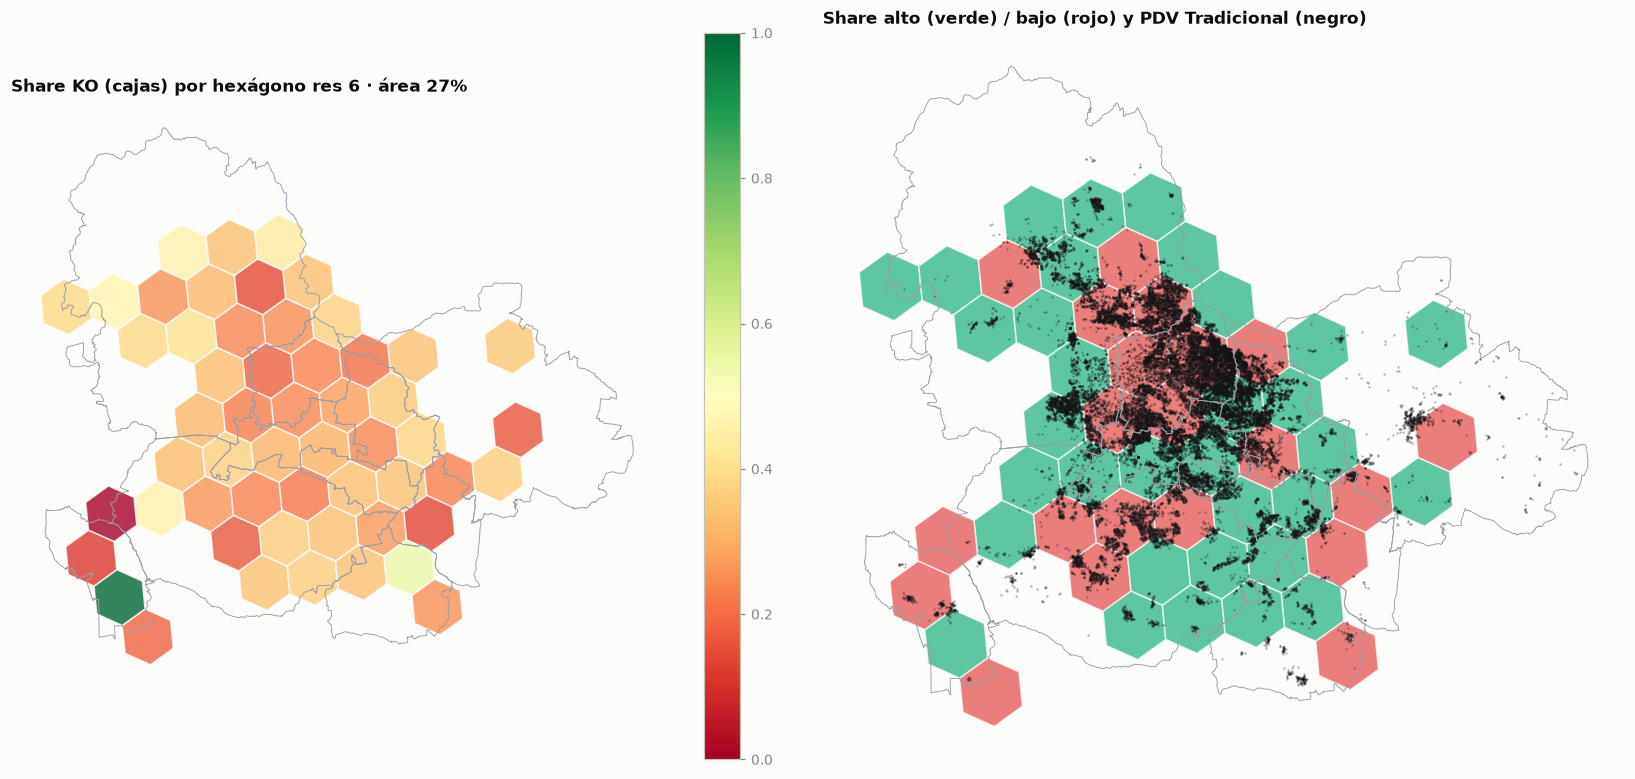

In [5]:
pdv_sh = pdv[["pos_id_cp", "hex6", "canal"]].join(sh, on="hex6")
pdv_sh["whisp_disponible"] = DISPONIBLE
pdv_sh["share_area"] = SHARE_AREA                     # share de Coca-Cola de toda el área (corte alto / bajo; lo usa el mapa del 06)
pdv_sh["fuente_share"] = np.where(pdv_sh.share_cajas.notna(), "Whisp (hexágono res 6)",
                                  "sin ventas en Whisp en su hexágono" if DISPONIBLE else "Whisp sin datos para el área")
print(pdv_sh.fuente_share.value_counts().to_string())
if DISPONIBLE:
    poly = gpd.GeoDataFrame(sh.reset_index(), geometry=[Polygon([(b, a) for a, b in h3.cell_to_boundary(h)]) for h in sh.index], crs=4326)
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))
    zm.boundary.plot(ax=ax[0], color="#999ea6", linewidth=0.6)
    poly.plot(ax=ax[0], column="share_cajas", cmap="RdYlGn", legend=True, alpha=0.8, edgecolor="white")
    ax[0].set_title(f"Share KO (cajas) por hexágono res 6 · área {SHARE_AREA:.0%}")
    zm.boundary.plot(ax=ax[1], color="#999ea6", linewidth=0.6)
    poly.plot(ax=ax[1], color=poly.share_clase.map({"alto": "#1baf7a", "bajo": "#e34948"}), alpha=0.7, edgecolor="white")
    t_ = pdv[pdv.canal == "Tradicional"]
    ax[1].scatter(t_.lon, t_.lat, s=0.3, c="#141417", alpha=0.3)
    ax[1].set_title("Share alto (verde) / bajo (rojo) y PDV Tradicional (negro)")
    for a_ in ax:
        a_.set_axis_off()
    plt.tight_layout(); plt.show()

## 5. Guardar (lo lee el 06)

In [6]:
pdv_sh.to_parquet(SALIDA, index=False)
resumen = pd.DataFrame([("Whisp disponible para el área", "sí" if DISPONIBLE else "no"),
                        ("Ventana", f"{C.WHISP_VENTANA[0]} → {C.WHISP_VENTANA[1]}"),
                        ("Hexágonos res 6 del área", len(area)), ("Hexágonos con ventas en Whisp", len(sh)),
                        ("Share KO del área (cajas)", f"{SHARE_AREA:.1%}" if DISPONIBLE else "no aplica · sin Whisp"),
                        ("Hexágonos con share alto", int((sh.share_clase == "alto").sum()) if DISPONIBLE else "no aplica · sin Whisp"),
                        ("PDV con share de Whisp", int(pdv_sh.share_cajas.notna().sum())),
                        ("Regla", "Prioridad = Letra 1 × share: H bajo P1 · H alto P2 · L bajo P3 · L alto P4; sin share, por letras")],
                       columns=["concepto", "valor"])
out = C.OUT / f"07_whisp_share_{C.CLIENTE}_{C.SLUG}.xlsx"
with pd.ExcelWriter(out) as xw:
    resumen.to_excel(xw, sheet_name="Resumen", index=False)
    hx = sh.round(4).reset_index().rename(columns={"index": "hex_res_6"})
    pri = ["hex_res_6", "Región", "SubTerritorio principal", "SubTerritorio", "Segmento"]
    hx = hx[[c_ for c_ in pri if c_ in hx] + [c_ for c_ in hx if c_ not in pri]]
    for c_ in [c_ for c_ in hx if c_.startswith("share KO ")]:   # sin celdas vacías sin motivo
        hx[c_] = hx[c_].astype(object).where(hx[c_].notna(), "sin venta de la categoría en el hexágono")
    hx.to_excel(xw, sheet_name="Share por hexágono", index=False)
    (fab.rename(columns={"unit_cases": "cajas unidad"}).round(2) if len(fab) else pd.DataFrame({"nota": ["no aplica · sin Whisp para el área"]})
     ).to_excel(xw, sheet_name="Fabricantes", index=False)
    (cats.round(2) if len(cats) else pd.DataFrame({"nota": ["no aplica · sin Whisp para el área"]})).to_excel(xw, sheet_name="Categorías", index=False)
display(resumen)
print(f"Guardado: {SALIDA.name} ({len(pdv_sh):,} PDV, {int(pdv_sh.share_cajas.notna().sum()):,} con share) | {out.name}")

,concepto,valor
0,Whisp disponible para el área,sí
1,Ventana,202508 → 202608
2,Hexágonos res 6 del área,91
3,Hexágonos con ventas en Whisp,54
4,Share KO del área (cajas),26.7%
5,Hexágonos con share alto,33
6,PDV con share de Whisp,38410
7,Regla,Prioridad = Letra 1 × share: H bajo P1 · H alt...


Guardado: whisp_share_arca_zm_guadalajara.parquet (39,236 PDV, 38,410 con share) | 07_whisp_share_arca_zm_guadalajara.xlsx
